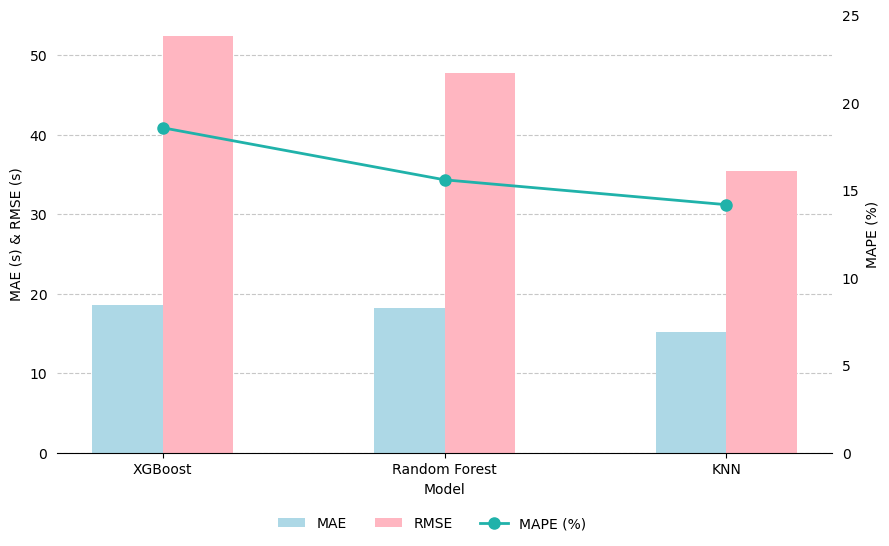

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

models = ['XGBoost', 'Random Forest', 'KNN']
mae = [18.61, 18.23, 15.21]
rmse = [52.45, 47.74, 35.49]
mape = [18.56, 15.59, 14.17]

df = pd.DataFrame({
    'Model': models,
    'MAE': mae,
    'RMSE': rmse,
    'MAPE (%)': mape
})
df

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_axisbelow(True)

width = 0.25

x = np.arange(len(models))

bars1 = ax1.bar(x - width/2, mae, width, label='MAE', color='#ADD8E6')
bars2 = ax1.bar(x + width/2, rmse, width, label='RMSE', color='#FFB6C1')

ax1.set_xlabel('Model')
ax1.set_ylabel('MAE (s) & RMSE (s)')
ax1.set_xticks(x)
ax1.set_xticklabels(models)

ax2 = ax1.twinx()
ax2.set_axisbelow(True)

line, = ax2.plot(x, mape, color='lightseagreen', marker='o', linestyle='-', 
                 linewidth=2, markersize=8, label='MAPE (%)')

ax2.set_ylabel('MAPE (%)')

# ax1.set_ylim(0, 25)
ax2.set_ylim(0, 25)

ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.tick_params(axis='y', left=False)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.tick_params(axis='y', right=False)

handles = [bars1, bars2, line]

fig.legend(handles=[bars1, bars2, line], 
           labels=['MAE', 'RMSE', 'MAPE (%)'],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.0),
           frameon=False,
           ncol=3)

plt.subplots_adjust(bottom=0.15)
plt.savefig('overall_comparison_plot.png')

plt.show()

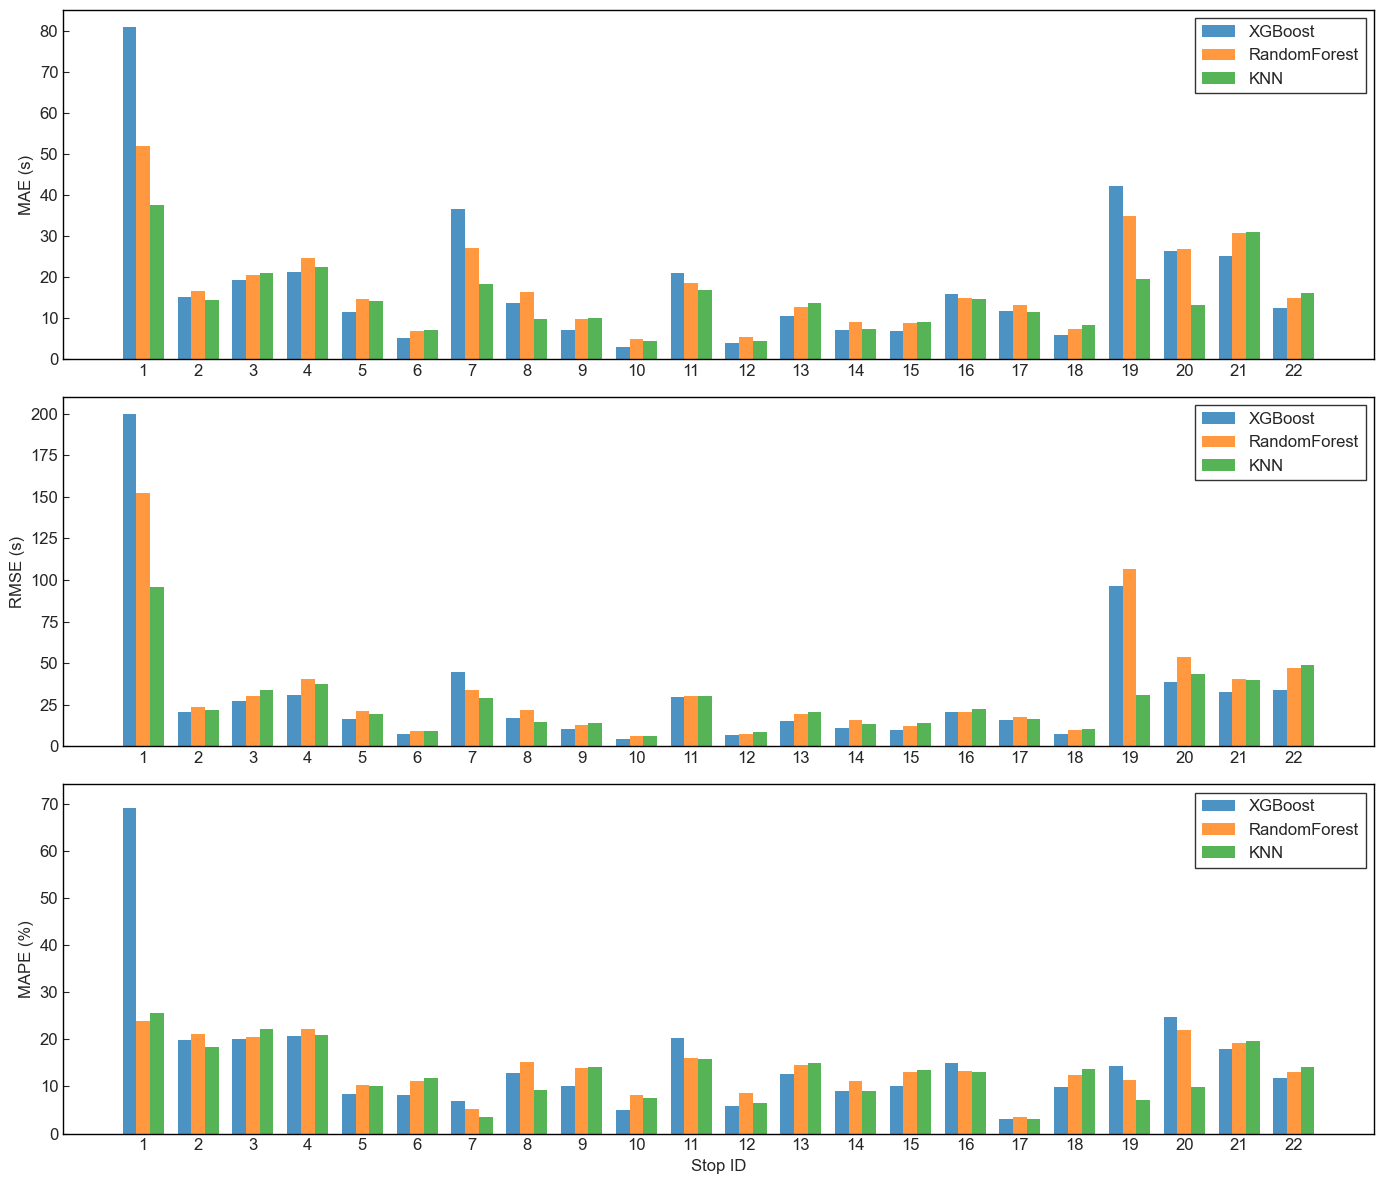

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (14, 10)

# Load CSV files
mae_df = pd.read_csv('AP1_compare_mae_ml.csv')
mape_df = pd.read_csv('AP1_compare_mape_ml.csv')
rmse_df = pd.read_csv('AP1_compare_rmse_ml.csv')

# Create figure and subplots (order: MAE, RMSE, MAPE)
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Define colors and model labels
models = ['XGBoost', 'RandomForest', 'KNN']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# Common x positions
x = np.arange(len(mae_df['STOP']))  # stop positions (0,1,...,14)
width = 0.25  # bar width

# --- Plot MAE (top) ---
ax = axes[0]
for i, model in enumerate(models):
    ax.bar(x + i*width, mae_df[model], width, label=model, color=colors[i], alpha=0.8)

ax.set_ylabel('MAE (s)')
ax.set_xticks(x + width)
ax.set_xticklabels(mae_df['STOP'])  # stop numbers 1-15
ax.xaxis.set_tick_params(labelbottom=True)  # show x-axis labels on this subplot
ax.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False)  # legend with border
ax.grid(False)  # Remove grid lines
ax.tick_params(axis='y', which='both', length=4, direction='in')  # y-axis ticks visible

# --- Plot RMSE (middle) ---
ax = axes[1]
for i, model in enumerate(models):
    ax.bar(x + i*width, rmse_df[model], width, label=model, color=colors[i], alpha=0.8)

ax.set_ylabel('RMSE (s)')
ax.set_xticks(x + width)
ax.set_xticklabels(mae_df['STOP'])
ax.xaxis.set_tick_params(labelbottom=True)  # show x-axis labels on this subplot
ax.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False)  # legend with border
ax.grid(False)  # Remove grid lines
ax.tick_params(axis='y', which='both', length=4, direction='in')  # y-axis ticks visible

# --- Plot MAPE (bottom) ---
ax = axes[2]
for i, model in enumerate(models):
    ax.bar(x + i*width, mape_df[model], width, label=model, color=colors[i], alpha=0.8)

ax.set_ylabel('MAPE (%)')
ax.set_xlabel('Stop ID')
ax.set_xticks(x + width)
ax.set_xticklabels(mae_df['STOP'])
ax.xaxis.set_tick_params(labelbottom=True)  # already True by default, but explicit
ax.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False)  # legend with border
ax.grid(False)  # Remove grid lines
ax.tick_params(axis='y', which='both', length=4, direction='in')  # y-axis ticks visible

# Set MAPE y-axis limit to max value + 5
max_mape = max(mape_df[models].max())  # get the maximum value across all models
ax.set_ylim(0, max_mape + 5)  # extend upper limit by 5

# Ensure all subplots have visible borders (black, linewidth=1)
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.savefig('stations_comparison_plot.png')
plt.show()

In [3]:
# ===== XGBoost =====
mape_xgb_base = 18.56
mape_xgb_avg  = 20.41
mape_xgb_best = 18.48
mape_xgb_non  = 21.08
best_p_xgb    = 0.93

# ===== Random Forest =====
mape_rf_base = 15.59
mape_rf_avg  = 19.45
mape_rf_best = 15.59
mape_rf_non  = 19.71
best_p_rf    = 1.00

# ===== KNN =====
mape_knn_base = 14.17
mape_knn_avg  = 18.12
mape_knn_best = 14.16
mape_knn_non  = 18.59
best_p_knn    = 0.98

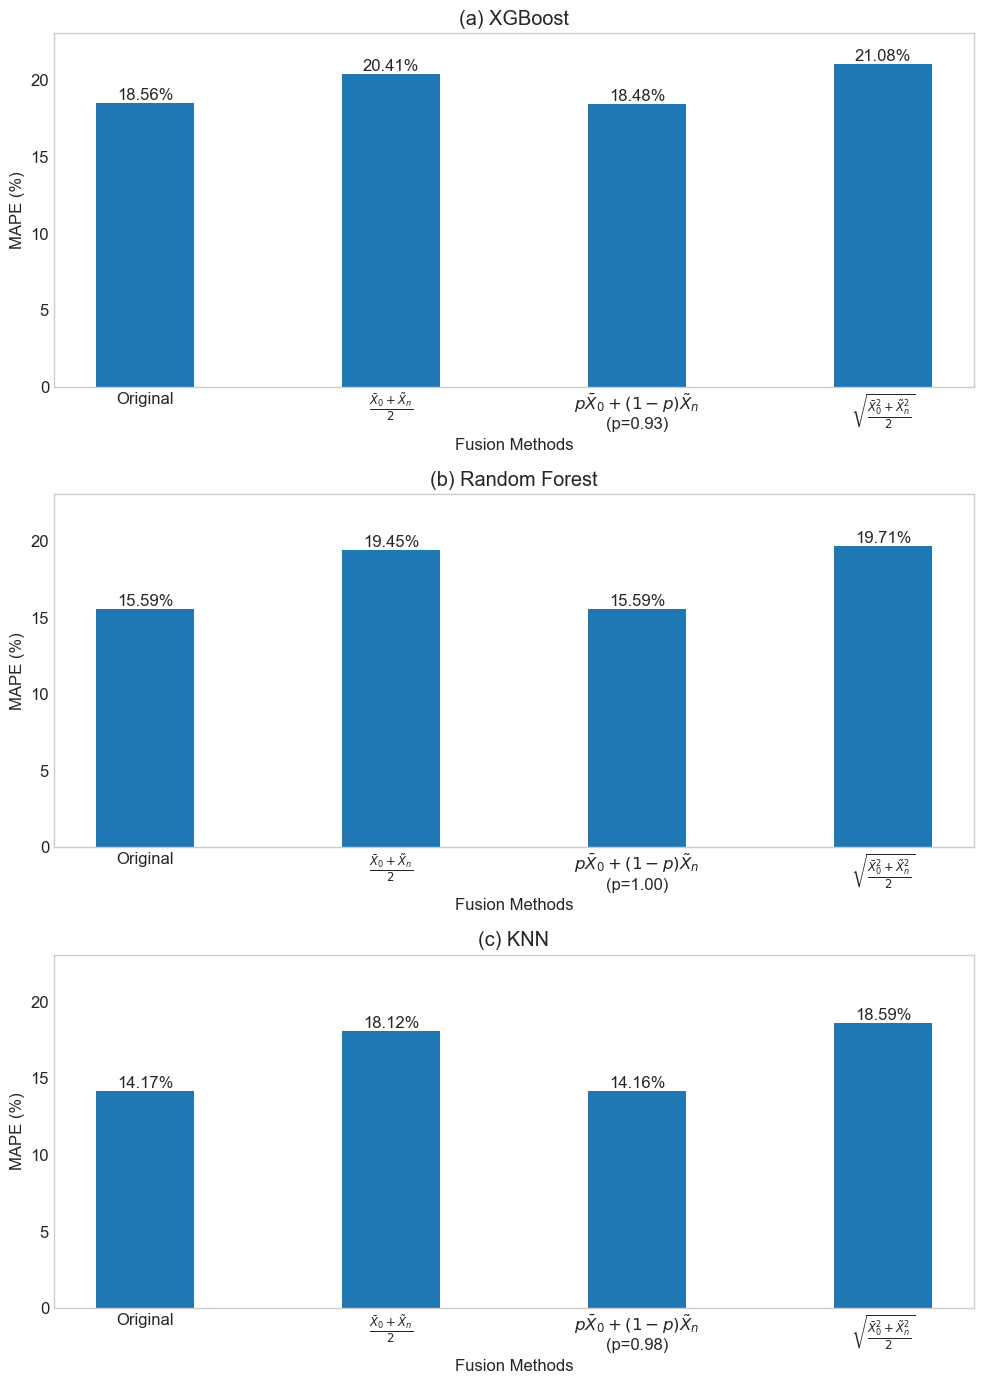

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 14))

def get_methods(best_p):
    return [
        'Original',
        r'$\frac{\bar{X}_0 + \tilde{X}_n}{2}$',
        rf'$p\bar{{X}}_0 + (1-p)\tilde{{X}}_n$' + f'\n(p={best_p:.2f})',
        r'$\sqrt{\frac{\bar{X}_0^2+\tilde{X}_n^2}{2}}$'
    ]

models = [
    ("(a) XGBoost",
     [mape_xgb_base, mape_xgb_avg, mape_xgb_best, mape_xgb_non],
     best_p_xgb),

    ("(b) Random Forest",
     [mape_rf_base, mape_rf_avg, mape_rf_best, mape_rf_non],
     best_p_rf),

    ("(c) KNN",
     [mape_knn_base, mape_knn_avg, mape_knn_best, mape_knn_non],
     best_p_knn),
]

for ax, (title, values, best_p) in zip(axes, models):

    methods = get_methods(best_p)

    ax.bar(methods, values, width=0.4)

    ax.set_title(title)
    ax.set_ylabel('MAPE (%)')
    ax.set_xlabel('Fusion Methods')
    ax.grid(False)


    for i, v in enumerate(values):
        ax.text(i, v, f"{v:.2f}%", ha='center', va='bottom')

all_values = (
    [mape_xgb_base, mape_xgb_avg, mape_xgb_best, mape_xgb_non] +
    [mape_rf_base, mape_rf_avg, mape_rf_best, mape_rf_non] +
    [mape_knn_base, mape_knn_avg, mape_knn_best, mape_knn_non]
)

y_max = max(all_values)

for ax in axes:
    ax.set_ylim(0, y_max + 2)

plt.tight_layout()

plt.savefig('fusion_comparison_all_models.pdf',
            dpi=300,
            bbox_inches='tight')

plt.show()